## Dependencias

In [11]:
# Data Wrangling
import os
# import zipfile
import numpy as np
import pandas as pd

import shutil
import random
from collections import Counter

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Modeling
import tensorflow as tf
from keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, Activation
from sklearn.utils.class_weight import compute_class_weight

# Data Visualization
import cufflinks as cf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, ImageDraw, ImageFont

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Configuración del notebook
cf.go_offline()
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.FATAL)

## Carpetas de Train y Val

In [12]:
ruta_train = r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Prácticas\Práctica II\CNN_Simpsons\simpsons_dataset\train"

ruta_val = r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Prácticas\Práctica II\CNN_Simpsons\simpsons_dataset\val"

## Mosaico

In [13]:
from mosaico_simpons import obtener_imagenes_simpsons, crear_mosaico_simpsons

imagenes = obtener_imagenes_simpsons(ruta_train, n_por_clase=4)

mosaico = crear_mosaico_simpsons(imagenes, columnas=6)

mosaico.show()

## Generadores

In [14]:
target_size = (150,150)

In [15]:
# Parámetros
BATCH_SIZE = 32

# Generador de entrenamiento 
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Generador de validación (SIN augmentación)
val_datagen = ImageDataGenerator(
    rescale=1./255
)

# Flow desde carpetas
train_generator = train_datagen.flow_from_directory(
    ruta_train,
    target_size=target_size,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    ruta_val,
    target_size=target_size,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 15185 images belonging to 18 classes.
Found 3807 images belonging to 18 classes.


In [16]:
X_batch, y_batch = next(train_generator)
print(f'Los índices de las clases son\n {train_generator.class_indices}')

Los índices de las clases son
 {'abraham_grampa_simpson': 0, 'apu_nahasapeemapetilon': 1, 'bart_simpson': 2, 'charles_montgomery_burns': 3, 'chief_wiggum': 4, 'comic_book_guy': 5, 'edna_krabappel': 6, 'homer_simpson': 7, 'kent_brockman': 8, 'krusty_the_clown': 9, 'lisa_simpson': 10, 'marge_simpson': 11, 'milhouse_van_houten': 12, 'moe_szyslak': 13, 'ned_flanders': 14, 'nelson_muntz': 15, 'principal_skinner': 16, 'sideshow_bob': 17}


## Modelado

In [17]:
model = Sequential()

# Bloque 1
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Bloque 2
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))

# Bloque 3
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.35))

# Clasificador
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(train_generator.num_classes, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,745,554 (40.99 MB)

 Trainable params: 10,745,554 (40.99 MB)

 Non-trainable params: 0 (0.00 B)

## Parámetros de Entrenamiento

In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Call backs

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',   # mejor que accuracy
    patience=10,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'models/model_simpsons_{val_accuracy:.3}.keras',
    save_best_only=True,
    save_weights_only=False,
    monitor='val_accuracy'
)

classes = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

In [19]:
# Entrenamiento del modelo

history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stopping, checkpoint],
    class_weight=class_weights
)

c:\Users\azayas\Diplomado\myenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 163s 340ms/step - accuracy: 0.1609 - loss: 2.6540 - val_accuracy: 0.3270 - val_loss: 2.3324
Epoch 2/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 133s 281ms/step - accuracy: 0.3253 - loss: 2.1082 - val_accuracy: 0.4854 - val_loss: 1.7333
Epoch 3/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 131s 275ms/step - accuracy: 0.4168 - loss: 1.7922 - val_accuracy: 0.5776 - val_loss: 1.4419
Epoch 4/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 128s 270ms/step - accuracy: 0.4966 - loss: 1.5467 - val_accuracy: 0.6470 - val_loss: 1.2180
Epoch 5/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 120s 253ms/step - accuracy: 0.5574 - loss: 1.3700 - val_accuracy: 0.6887 - val_loss: 1.0589
Epoch 6/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 125s 263ms/step - accuracy: 0.6026 - loss: 1.2401 - val_accuracy: 0.7118 - val_loss: 1.0302
Epoch 7/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 135s 285ms/step - accuracy: 0.6316 - loss: 1.1309 - val_accuracy: 0.7344 - val_loss: 0.9408
Epoch 8/25
475/475 ━━━━━━━━━━━━━━━━━━━━ 153s 322ms/step - accuracy: 0.6559 -

## Evaluación del Modelo

### Resultados de Entrenamiento

In [20]:
results = pd.DataFrame(history.history)
results

,accuracy,loss,val_accuracy,val_loss
0,0.160882,2.654024,0.327029,2.332428
1,0.325255,2.108168,0.485422,1.733315
2,0.416793,1.792176,0.577620,1.441899
3,0.496608,1.546682,0.646966,1.217989
4,0.557392,1.370016,0.688731,1.058935
5,0.602568,1.240149,0.711847,1.030170
6,0.631610,1.130936,0.734437,0.940833
7,0.655910,1.062430,0.765169,0.816451
8,0.678828,0.986451,0.781455,0.751619
9,0.692921,0.934008,0.788810,0.750588


### Calificación de Validate

In [24]:
best_model_name = sorted(os.listdir('./models'))[-1]
print(best_model_name)

best_model = tf.keras.models.load_model(
    os.path.join(
        './models',
        best_model_name
    )
)

model_simpsons_0.887.keras


In [25]:
val_loss, val_acc = best_model.evaluate(val_generator)
print(f'Validation loss: {val_loss}')
print(f'Validation accuracy {val_acc}')

119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8871 - loss: 0.4073
Validation loss: 0.40725162625312805
Validation accuracy 0.8870501518249512


119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step


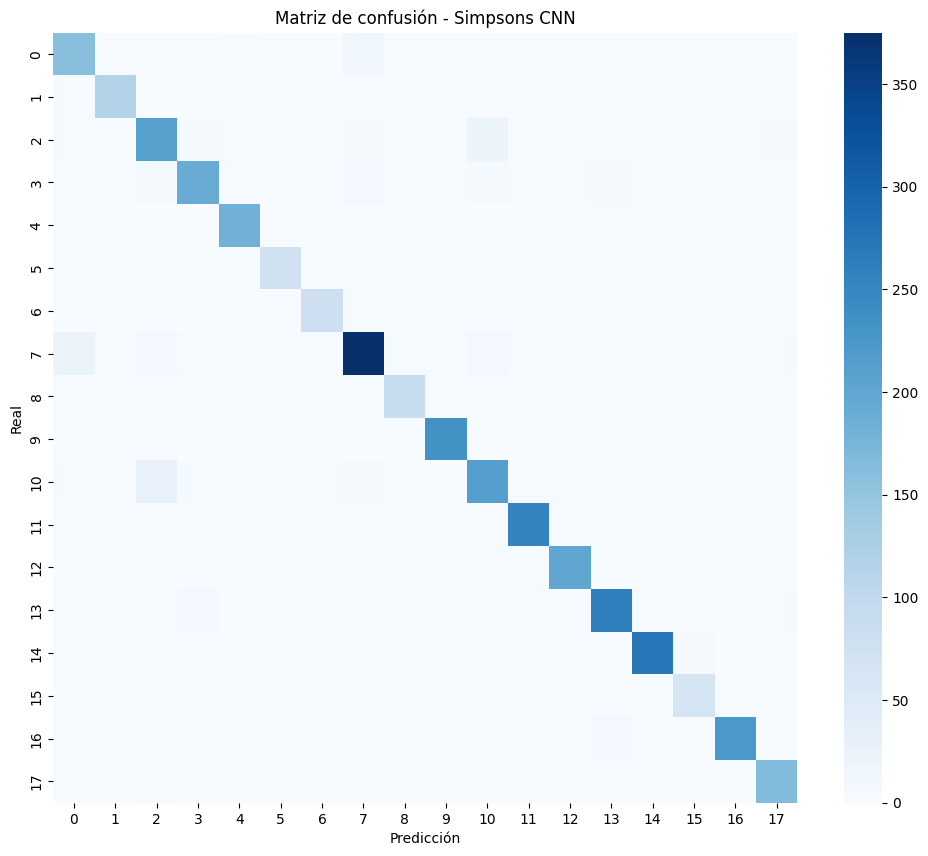

In [26]:
# Predicciones sobre validation
pred_probs = best_model.predict(val_generator)
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())


cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Matriz de confusión - Simpsons CNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [27]:
print(classification_report(true_classes, pred_classes, target_names=class_labels))

                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.82      0.88      0.85       183
  apu_nahasapeemapetilon       0.96      0.94      0.95       125
            bart_simpson       0.79      0.78      0.79       269
charles_montgomery_burns       0.86      0.80      0.83       239
            chief_wiggum       0.92      0.92      0.92       198
          comic_book_guy       0.92      0.81      0.86        94
          edna_krabappel       0.82      0.89      0.85        92
           homer_simpson       0.87      0.83      0.85       450
           kent_brockman       0.87      0.90      0.89       100
        krusty_the_clown       0.93      0.97      0.95       242
            lisa_simpson       0.83      0.79      0.81       271
           marge_simpson       0.93      0.98      0.95       259
     milhouse_van_houten       0.94      0.94      0.94       216
             moe_szyslak       0.90      0.90      0.90       291
         